# Лабораторная работа № 2: Теплоперенос в слоистых материалах

### Выполнил: <font color='red'>Казанцева Варвара Денисовна, МГУ, ВМК гр. 608</font>

**Материал:** GaN (cubic) 


**Цель работы:** Построить двухмасштабную модель теплопереноса, рассчитать теплоёмкость и теплопроводность с помощью пакета almaBTE.


## Часть 1. Теплоперенос в слоистых материалах

### 1. Теоретические сведения

- Энергия кристалла разлагается в ряд Тейлора:

$$
E = E_0 + \frac{1}{2} \sum_{ij,\alpha\beta} \Phi_{ij}^{\alpha\beta} u_i^\alpha u_j^\beta + \frac{1}{6} \sum_{ijk,\alpha\beta\gamma} \Psi_{ijk}^{\alpha\beta\gamma} u_i^\alpha u_j^\beta u_k^\gamma + \dots
$$

- Физические величины:
  - $\Phi_{ij}^{\alpha\beta}$ — силовые константы 2-го порядка  
  - $\Psi_{ijk}^{\alpha\beta\gamma}$ — силовые константы 3-го порядка

- Для исключения взаимодействия с периодическими образами используется **суперячейка**.


In [9]:
import os
import subprocess
import pandas as pd
import matplotlib.pyplot as plt





**almaBTE (ALMA Boltzmann Transport Equation solver)** — программный пакет для расчёта тепловых свойств кристаллов на основе:
- гармонических и ангармонических силовых констант (2-го и 3-го порядка);
- решения уравнения Больцмана для фононов;
- учёта рассеяния на изотопах, дефектах и границах.


In [3]:
# Пути к almaBTE
alma_path = os.path.expanduser('~/Programs/almabte-v1.3.2/build/src')
os.environ['PATH'] += os.pathsep + alma_path

### 2. Формирование базы данных (VCAbuilder)
- Назначение: формирование базы данных кристалла на основе силовых констант 2-го и 3-го порядка.  

- Входной файл (`*.xml`): содержит ссылки на репозиторий материалов (`materials_repository`), имя исследуемого соединения (`compound`), плотность сетки (`gridDensity`) и каталог для сохранения результатов. 

- Результат: HDF5-база данных с фононными свойствами материала.

In [13]:
subprocess.run(['mpirun', '-n', '4', 'VCAbuilder', 'GaN.xml'])

PARSING GaN.xml ...
***********************************
This is ALMA/VCAbuilder version 1.3
***********************************
Generating polar singlecrystal GaN_cubic
Loading POSCAR
Loading force constants 2nd order
Loading force constants 3rd order
Calculating symmetries
Generating 24x24x24 wavevector grid
Finding 3-phonon processes
Computing matrix elements
  1% 	  2% 	  3% 	  4% 	  5% 	  6% 	  7% 	  8% 	  9% 	  10% 	
  11% 	  12% 	  13% 	  14% 	  15% 	  16% 	  17% 	  18% 	  19% 	  20% 	
  21% 	  22% 	  23% 	  24% 	  25% 	  26% 	  27% 	  28% 	  29% 	  30% 	
  31% 	  32% 	  33% 	  34% 	  35% 	  36% 	  37% 	  38% 	  39% 	  40% 	
  41% 	  42% 	  43% 	  44% 	  45% 	  46% 	  47% 	  48% 	  49% 	  50% 	
  51% 	  52% 	  53% 	  54% 	  55% 	  56% 	  57% 	  58% 	  59% 	  60% 	
  61% 	  62% 	  63% 	  64% 	  65% 	  66% 	  67% 	  68% 	  69% 	  70% 	
  71% 	  72% 	  73% 	  74% 	  75% 	  76% 	  77% 	  78% 	  79% 	  80% 	
  81% 	  82% 	  83% 	  84% 	  85% 	  86% 	  87% 	  88% 	  89% 	  90% 	
  91% 

CompletedProcess(args=['mpirun', '-n', '4', 'VCAbuilder', 'GaN.xml'], returncode=0)

### 3. kappa_Tsweep

- Назначение: расчёт теплопроводности и теплоёмкости в зависимости от температуры.

- Входной файл (`*-kappa.xml`): задаёт диапазон температур (`sweep`), направление переноса тепла (`transportAxis`), уточнение расчёта (`опция <fullBTE/>`) и параметры вывода.

- Результат: CSV-файл с таблицей зависимости теплопроводности и теплоемкости от температуры.

In [8]:
subprocess.run(['kappa_Tsweep', 'GaN-kappa.xml'])

*************************************
This is ALMA/kappa_Tsweep version 1.3
*************************************
PARSING GaN-kappa.xml ...
Opening HDF5 file "./GaN/GaN_cubic_24_24_24.h5"
Running Tsweep for GaN_cubic
 Processing 100 K (temperature 1 of 10)
 Processing 200 K (temperature 2 of 10)
 Processing 300 K (temperature 3 of 10)
 Processing 400 K (temperature 4 of 10)
 Processing 500 K (temperature 5 of 10)
 Processing 600 K (temperature 6 of 10)
 Processing 700 K (temperature 7 of 10)
 Processing 800 K (temperature 8 of 10)
 Processing 900 K (temperature 9 of 10)
 Processing 1000 K (temperature 10 of 10)

Writing to file GaN_cubic_24_24_24_0,0,1_100_1000.Tsweep
in subdirectory ./GaN
under root directory "/home/varvara/Учеба/magistr_3sem/MM/lab2"

[DONE.]


CompletedProcess(args=['kappa_Tsweep', 'GaN-kappa.xml'], returncode=0)

In [13]:
# Путь к файлу с результатами
results_file = './GaN/GaN_cubic_24_24_24_0,0,1_100_1000.Tsweep'

# Чтение файла, игнорируя сложные заголовки
data = pd.read_csv(results_file, skiprows=0, names=['Temp', 'kappaRTA', 'kappaBTE', 'Cbulk'], header=1)


data.head()

,Temp,kappaRTA,kappaBTE,Cbulk
0,200,329.420,353.621,1947900.0
1,300,228.379,247.656,2615330.0
2,400,179.409,195.744,3004800.0
3,500,149.579,163.917,3231990.0
4,600,129.029,141.879,3371330.0


####  Результаты расчётов теплопроводности и теплоёмкости GaN

В результате расчётов в almaBTE был получен CSV-файл с четырьмя основными колонками:

| Колонка       | Обозначение | Единицы измерения | Описание |
|---------------|-------------|-----------------|----------|
| `Temp`        | Температура | К               | Температура кристалла, при которой рассчитаны свойства |
| `kappaRTA`    | Теплопроводность в RTA | Вт/(м·К)          | Коэффициент теплопроводности, рассчитанный в **приближении времени релаксации (RTA)** |
| `kappaBTE`    | Теплопроводность в BTE | Вт/(м·К)          | Коэффициент теплопроводности, рассчитанный решением **полного уравнения Больцмана для фононов (BTE)** |
| `Cbulk`       | Теплоёмкость | Дж/(м³·К)        | Объёмная теплоёмкость кристалла при данной температуре |

#### Пояснения:

- **kappaRTA** обычно даёт приближённое значение теплопроводности, быстрее в расчёте, но менее точное.  
- **kappaBTE** учитывает полное взаимодействие фононов, поэтому считается более точным.  
- **Cbulk** показывает, сколько энергии необходимо для нагрева единицы объёма кристалла на 1 Кельвин.  



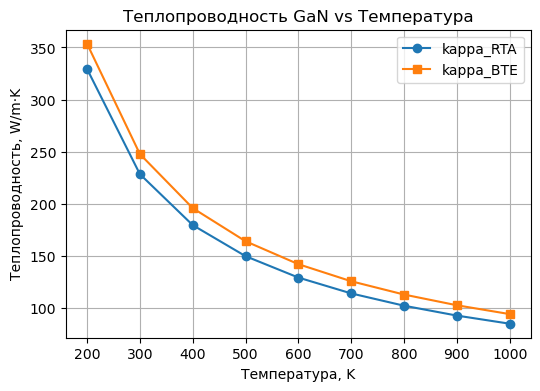

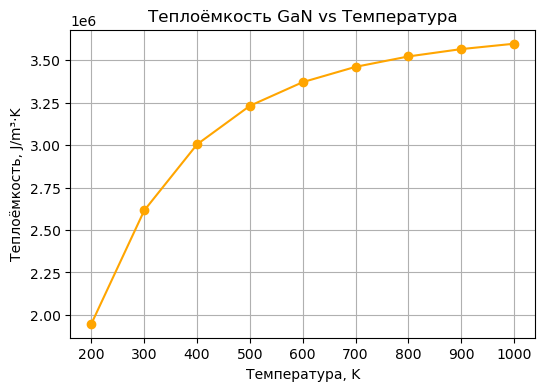

In [14]:
# Графики
plt.figure(figsize=(6,4))
plt.plot(data['Temp'], data['kappaRTA'], marker='o', label='kappa_RTA')
plt.plot(data['Temp'], data['kappaBTE'], marker='s', label='kappa_BTE')
plt.xlabel('Температура, K')
plt.ylabel('Теплопроводность, W/m·K')
plt.title('Теплопроводность GaN vs Температура')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(data['Temp'], data['Cbulk'], marker='o', color='orange')
plt.xlabel('Температура, K')
plt.ylabel('Теплоёмкость, J/m³·K')
plt.title('Теплоёмкость GaN vs Температура')
plt.grid(True)
plt.show()

### 4. kappa_crossplanefilms

- **Назначение:** расчёт теплопроводности тонкой плёнки поперёк её толщины.  

- **Входной файл (`*-crossplane.xml`):** задаёт толщины плёнки (`sweep`), направление переноса тепла (`transportAxis`) и параметры вывода (`target`).  

- **Дополнительно:** можно указать температуру окружающей среды вторым параметром (по умолчанию 300 К).  

- **Результат:** CSV-файл с зависимостью теплопроводности от толщины плёнки.


In [15]:
subprocess.run(['kappa_crossplanefilms', 'GaN-crossplane.xml', '300'])

**********************************************
This is ALMA/kappa_crossplanefilms version 1.3
**********************************************
PARSING GaN-crossplane.xml ...
Opening HDF5 file "./GaN/GaN_cubic_24_24_24.h5"

Computing cross-plane film conductivities for GaN_cubic at 300K

Writing film conductivities to file GaN_cubic_24_24_24_0,0,1_300K_1nm_100um.crossplanefilms
in directory ./GaN
under base directory "/home/varvara/Учеба/magistr_3sem/MM/lab2"

[DONE.]


CompletedProcess(args=['kappa_crossplanefilms', 'GaN-crossplane.xml', '300'], returncode=0)

In [20]:
crossplane_file = './GaN/GaN_cubic_24_24_24_0,0,1_300K_1nm_100um.crossplanefilms'

column_names = ['thickness', 'kappa', 'kappa_ratio']
crossplane_data = pd.read_csv(crossplane_file, names=column_names, header=1)

crossplane_data.head()

,thickness,kappa,kappa_ratio
0,1.258930e-09,1.60973,0.007049
1,1.584890e-09,2.00479,0.008778
2,1.995260e-09,2.49200,0.010912
3,2.511890e-09,3.09094,0.013534
4,3.162280e-09,3.82463,0.016747


| Колонка       | Обозначение                           | Единицы измерения | Описание                                      |
| ------------- | ------------------------------------- | ----------------- | --------------------------------------------- |
| `thickness`   | Толщина плёнки                        | м                 | Толщина тонкой плёнки                         |
| `kappa`       | Теплопроводность                      | Вт/(м·К)          | Теплопроводность вдоль выбранного направления |
| `kappa_ratio` | Отношение к объёмной теплопроводности | —                 | `kappa / kappa_bulk`                          |


#### Пояснения:

- **kkappa** показывает, как изменяется теплопроводность при уменьшении толщины плёнки.

- **kkappa_ratio** позволяет быстро оценить снижение теплопроводности относительно объёмного кристалла.

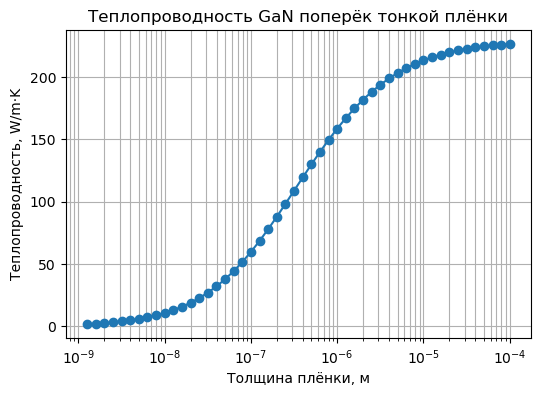

In [21]:
# График зависимости теплопроводности от толщины плёнки
plt.figure(figsize=(6,4))
plt.plot(crossplane_data['thickness'], crossplane_data['kappa'], marker='o')
plt.xscale('log')  # так как sweep логарифмический
plt.xlabel('Толщина плёнки, м')
plt.ylabel('Теплопроводность, W/m·K')
plt.title('Теплопроводность GaN поперёк тонкой плёнки')
plt.grid(True, which='both')
plt.show()


### 5. kappa_inplanefilms

- **Назначение:** расчёт зависимости теплопроводности тонкой плёнки вдоль плоскости плёнки от её толщины. 
 
- **Входной файл (`*-inplane.xml`):** задаёт диапазон толщин плёнки (`sweep`), направление переноса тепла (`transportAxis`), нормаль к поверхности плёнки (`normalAxis`) и директорию для результатов. 

- **Дополнительно:** вторым параметром можно указать температуру окружающей среды (по умолчанию 300 K).  

- **Результат:** CSV-файл с таблицей зависимости теплопроводности вдоль плёнки от толщины.

In [22]:
subprocess.run(['kappa_inplanefilms', 'GaN-inplane.xml', '300'])

*******************************************
This is ALMA/kappa_inplanefilms version 1.3
*******************************************
PARSING GaN-inplane.xml ...
Opening HDF5 file "./GaN/GaN_cubic_24_24_24.h5"

Computing in-plane film conductivities for GaN_cubic at 300K

Writing film conductivities to file GaN_cubic_24_24_24_u1,0,0_n0,0,1_specul0_300K_1nm_100um.inplanefilms
in directory ./GaN
under base directory "/home/varvara/Учеба/magistr_3sem/MM/lab2"

[DONE.]


CompletedProcess(args=['kappa_inplanefilms', 'GaN-inplane.xml', '300'], returncode=0)

In [25]:
inplane_file = './GaN/GaN_cubic_24_24_24_u1,0,0_n0,0,1_specul0_300K_1nm_100um.inplanefilms'

# Явно задаём имена колонок
column_names = ['thickness', 'kappa', 'kappa_ratio']
inplane_data = pd.read_csv(inplane_file, names=column_names, header=1)

inplane_data.head()

,thickness,kappa,kappa_ratio
0,1.258930e-09,32.2851,0.141353
1,1.584890e-09,33.5215,0.146766
2,1.995260e-09,34.9749,0.153129
3,2.511890e-09,36.6767,0.160580
4,3.162280e-09,38.6605,0.169266


| Колонка       | Обозначение                           | Единицы измерения | Описание                                |
| ------------- | ------------------------------------- | ----------------- | --------------------------------------- |
| `thickness`   | Толщина плёнки                        | м                 | Толщина тонкой плёнки                   |
| `kappa`       | Теплопроводность                      | Вт/(м·К)          | Теплопроводность вдоль плоскости плёнки |
| `kappa_ratio` | Отношение к объёмной теплопроводности | —                 | `kappa / kappa_bulk`                    |




#### Пояснения:

- **kkappa** показывает теплопроводность вдоль плёнки для разных толщин.

- **kappa_ratio** позволяет оценить, насколько сильно снижена теплопроводность относительно объёмного кристалла.

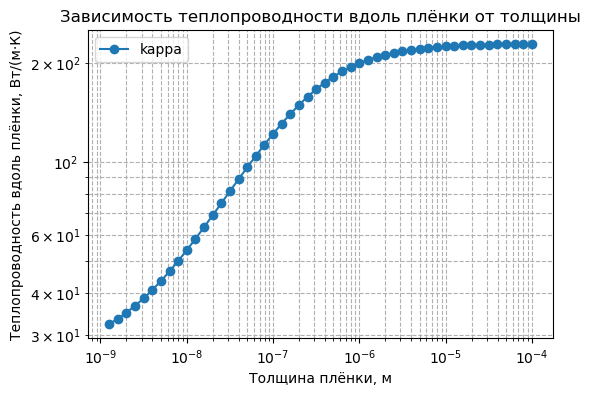

In [26]:
# График зависимости kappa от толщины плёнки
plt.figure(figsize=(6,4))
plt.loglog(inplane_data['thickness'], inplane_data['kappa'], marker='o', label='kappa')
plt.xlabel('Толщина плёнки, м')
plt.ylabel('Теплопроводность вдоль плёнки, Вт/(м·К)')
plt.title('Зависимость теплопроводности вдоль плёнки от толщины')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

## Часть 2. Методы машинного обучения

In [3]:
import os
import subprocess
import re
import pandas as pd
from itertools import product

In [4]:
# Пути к almaBTE
alma_path = os.path.expanduser('~/Programs/almabte-v1.3.2/build/src')
os.environ['PATH'] += os.pathsep + alma_path

project_dir = os.getcwd()

## 1. Расчёты теплопроводности

### Задание слоистой структуры

#### Модель Мураки для задания слоёв суперрешётки

Для задания доли материалов в слоях используется **модель Мураки**, которая описывает распределение второго материала по слоям. Доля во втором материале вычисляется по следующей формуле:

$$
f(\lambda) =
\begin{cases}
1 - R^{\lambda}, & \lambda \leq x \\
(1 - R^x) \cdot R^{\lambda - x}, & \lambda > x
\end{cases}
$$

где:  
- $\lambda$ — номер слоя,  
- $x$ — количество слоёв одного типа,  
- $R$ — параметр модели (от 0 до 0.9).  

Модель позволяет гибко задавать профили распределения состава в гетероструктуре.


Теперь необходимо произвести множество расчётов в котором необходимо
проварьировать параметр $R$ (от 0 до 0.9) и количество слоёв каждого типа в
модели (от 2 до 20).

In [5]:
def build_superlattice(R: float, x1: int, x2: int) -> str:
    """Генерация структуры и запуск superlattice_builder.
       Возвращает stem (имя .h5 файла без расширения и размера сетки)."""
    
    total_layers = x1 + x2  # Общее количество слоёв
    layers = []
    
    # Генерируем доли материалов для каждого слоя по модели Мураки
    for lam in range(1, total_layers + 1):
        if lam <= x1:
            # Первые x1 слоёв
            f = 1 - R**lam
        else:
            # Следующие x2 слоёв
            f = (1 - R**x1) * (R**(lam - x1))
        layers.append(f)

    layers_xml = "\n".join([f'  <layer mixfraction="{val:.10f}"/>' for val in layers])

    xml_content = f"""<superlattice>
  <materials_repository root_directory="./data"/>
  <gridDensity A="24" B="24" C="24"/>
  <compound name="AlN_cubic"/>
  <compound name="GaN_cubic"/>
  <normal na="0" nb="0" nc="1" nqline="501"/>
{layers_xml}
  <target directory="./AlN_GaN"/>
</superlattice>
"""
    xml_file = os.path.join(project_dir, f"AlN_GaN_R{R}_x1_{x1}_x2_{x2}.xml")
    with open(xml_file, "w") as f:
        f.write(xml_content)

    print(f"[INFO] Создан {xml_file} с {x1}+{x2} слоями, R={R}")

    try:
        proc = subprocess.run(["mpirun", "-n", "4", "superlattice_builder", xml_file], 
                            capture_output=True, text=True, cwd=project_dir)
    except Exception as e:
        raise RuntimeError(f"Ошибка запуска subprocess: {e}")

    # Проверяем код возврата
    if proc.returncode != 0:
        print("[ERROR] superlattice_builder завершился с ошибкой")
        print("stdout:\n", proc.stdout)
        print("stderr:\n", proc.stderr)
        raise RuntimeError(f"superlattice_builder вернул код {proc.returncode}")

    # Ищем имя созданного файла в выводе
    match = re.search(r"Target filename:\s*\S+(superlattice_\S+)_24_24_24\.h5", proc.stdout)
    if not match:
        # Альтернативный поиск
        match = re.search(r"(superlattice_\S+)_24_24_24\.h5", proc.stdout)
    
    if match:
        stem = match.group(1)
        print("[INFO] Суперрешетка построена, основая часть имени файла:", stem)
        return stem
    else:
        print("Полный вывод superlattice_builder:")
        print(proc.stdout)
        raise RuntimeError("Не удалось найти имя .h5 в выводе superlattice_builder")

In [6]:
def compute_kappa(stem: str, R: float, x1: int, x2: int, temp: int) -> pd.DataFrame:
    """Запуск kappa_crossplanefilms для данного stem и температуры.
       Возвращает DataFrame с результатами и добавленными параметрами."""
    
    xml_content = f'''<crossplanefilmsweep>
  <H5repository root_directory="."/>
  <compound directory="./AlN_GaN" base="{stem}" gridA="24" gridB="24" gridC="24"/>
  <sweep type="log" start="1e-9" stop="1e-4" points="51"/>
  <temperature K="{temp}"/>
  <transportAxis x="0" y="0" z="1"/>
  <target directory="result" file="AUTO"/>
</crossplanefilmsweep>
'''
    xml_file = os.path.join(project_dir, f"{stem}_T{temp}.xml")
    with open(xml_file, "w") as f:
        f.write(xml_content)

    # Создаем директорию result если её нет
    os.makedirs(os.path.join(project_dir, "result"), exist_ok=True)

    try:
        proc = subprocess.run(["kappa_crossplanefilms", xml_file], 
                            capture_output=True, text=True, cwd=project_dir)
    except Exception as e:
        raise RuntimeError(f"Ошибка запуска kappa_crossplanefilms: {e}")
    
    # Ищем имя созданного CSV файла
    match = re.search(r"Writing film conductivities to file\s+(\S+\.crossplanefilms)", proc.stdout)
    if not match:
        match = re.search(r"(\S+\.crossplanefilms)", proc.stdout)
    
    if match:
        csv_filename = match.group(1)
        csv_path = os.path.join(project_dir, "result", csv_filename)
        print("[INFO] Подсчет теплопроводности завершен, результаты в:", csv_path)
        
        # Читаем результаты
        df = pd.read_csv(csv_path)
        df = df.iloc[:, :2]  # первые два столбца
        df.columns = ["thickness", "crossplane"]
        df["r"] = R
        df["x"] = x1
        df["y"] = x2
        df["t"] = temp
        return df
    else:
        print("Полный вывод kappa_crossplanefilms:")
        print(proc.stdout)
        raise RuntimeError("Не удалось найти имя .crossplanefilms в выводе kappa_crossplanefilms")

In [7]:
def data_generator(R_values, layer_counts, temperatures):
    """Генератор данных с различными сочетаниями параметров"""
    results = []
    total_combinations = len(R_values) * len(layer_counts) * len(layer_counts) * len(temperatures)
    current_combination = 0

    for R in R_values:
        for x1, x2 in product(layer_counts, repeat=2):
            current_combination += 1
            print(f"\n[PROGRESS] Обрабатывается комбинация {current_combination}/{total_combinations}: R={R}, x1={x1}, x2={x2}")
            
            try:
                stem = build_superlattice(R, x1, x2)
            except Exception as e:
                print(f"[ERROR] Ошибка в superlattice R={R}, x1={x1}, x2={x2}: {e}")
                continue  # Продолжаем со следующей комбинацией

            for temp in temperatures:
                try:
                    df = compute_kappa(stem, R, x1, x2, temp)
                    results.append(df)
                    print(f"[SUCCESS] Успешно обработано: R={R}, x1={x1}, x2={x2}, T={temp}K")
                except Exception as e:
                    print(f"[ERROR] Ошибка в kappa R={R}, x1={x1}, x2={x2}, T={temp}: {e}")
                    continue

    if results:
        final_df = pd.concat(results, ignore_index=True)
        final_df.to_csv("dataset.csv", index=False)
        print(f"\n[DONE] Сохранён dataset.csv")

    else:
        print("[ERROR] Не удалось получить ни одной записи")

In [ ]:
# ---------------- Основной цикл ----------------

R_values = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9]
layer_counts = [2, 5, 10, 20]
temperatures = [300, 400, 500]

data_generator(R_values, layer_counts, temperatures)

## 2. Аппроксимационные модели

In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import clone
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, max_error
import matplotlib.pyplot as plt
import numpy as np

In [29]:
df = pd.read_csv('dataset.csv')

# Разделение на признаки и целевую переменную
X = df[['r', 'x', 'y', 't', 'thickness']]
y = df['crossplane']

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Размер обучающей выборки: {len(X_train)}")
print(f"Размер тестовой выборки: {len(X_test)}")

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Размер обучающей выборки: 10281
Размер тестовой выборки: 4407


### Линейная регрессия

Линейная регрессия:
MSE: 17.477756
R²: 0.316488
Max Error: 20.551515


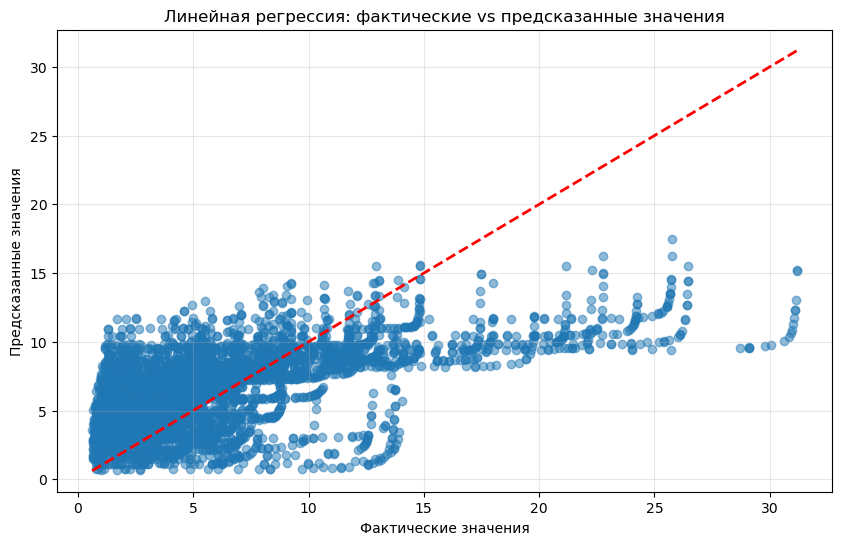

In [30]:
# Модель линейной регрессии
lr_model = LinearRegression()

# Обучение модели
lr_model.fit(X_train_scaled, y_train)

# Предсказание
lr_pred = lr_model.predict(X_test_scaled)

# Оценка модели
lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)
lr_max_err = max_error(y_test, lr_pred)

print("Линейная регрессия:")
print(f"MSE: {lr_mse:.6f}")
print(f"R²: {lr_r2:.6f}")
print(f"Max Error: {lr_max_err:.6f}")

# Визуализация результатов
plt.figure(figsize=(10, 6))
plt.scatter(y_test, lr_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title('Линейная регрессия: фактические vs предсказанные значения')
plt.grid(True, alpha=0.3)
plt.show()

### Метод опорных векторов (SVR)

In [31]:
# Модель SVR с оптимизацией гиперпараметров
svr_model = SVR()

# Поиск лучших гиперпараметров
param_grid = {
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.5, 1],
    'kernel': ['rbf', 'linear']
}

grid_search = GridSearchCV(
    svr_model, 
    param_grid, 
    cv=5, 
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

# Лучшая модель
best_svr = grid_search.best_estimator_
svr_pred = best_svr.predict(X_test_scaled)

# Оценка модели
svr_mse = mean_squared_error(y_test, svr_pred)
svr_r2 = r2_score(y_test, svr_pred)
svr_max_err = max_error(y_test, svr_pred)

print("\nМетод опорных векторов (SVR):")
print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"MSE: {svr_mse:.6f}")
print(f"R²: {svr_r2:.6f}")
print(f"Max Error: {svr_max_err:.6f}")


Метод опорных векторов (SVR):
Лучшие параметры: {'C': 100, 'epsilon': 1, 'kernel': 'rbf'}
MSE: 6.704084
R²: 0.737820
Max Error: 14.314422


In [32]:
print(f"Лучшие параметры: {grid_search.best_params_}")

Лучшие параметры: {'C': 100, 'epsilon': 1, 'kernel': 'rbf'}


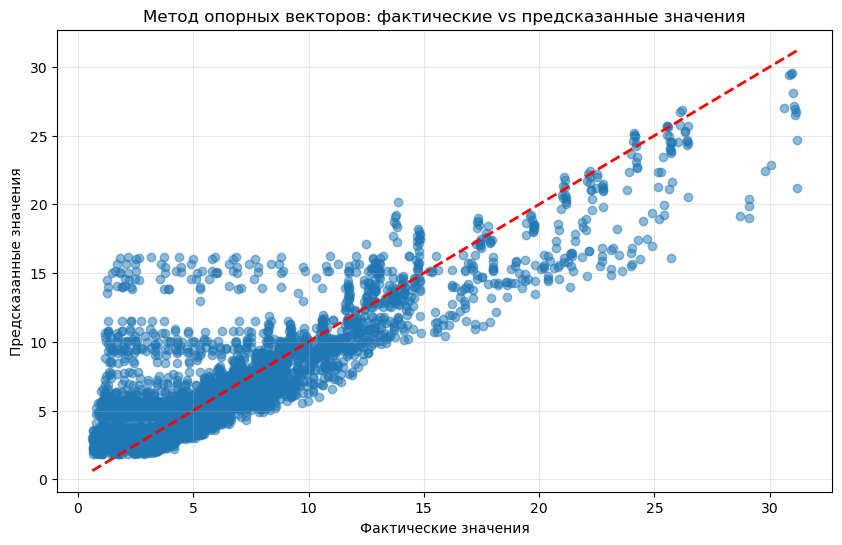

In [33]:
# Визуализация результатов
plt.figure(figsize=(10, 6))
plt.scatter(y_test, svr_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title('Метод опорных векторов: фактические vs предсказанные значения')
plt.grid(True, alpha=0.3)
plt.show()

### Градиентный бустинг (Gradient Boosting)

Градиентный бустинг:
MSE: 0.692229
R²: 0.972929
Max Error: 4.071449


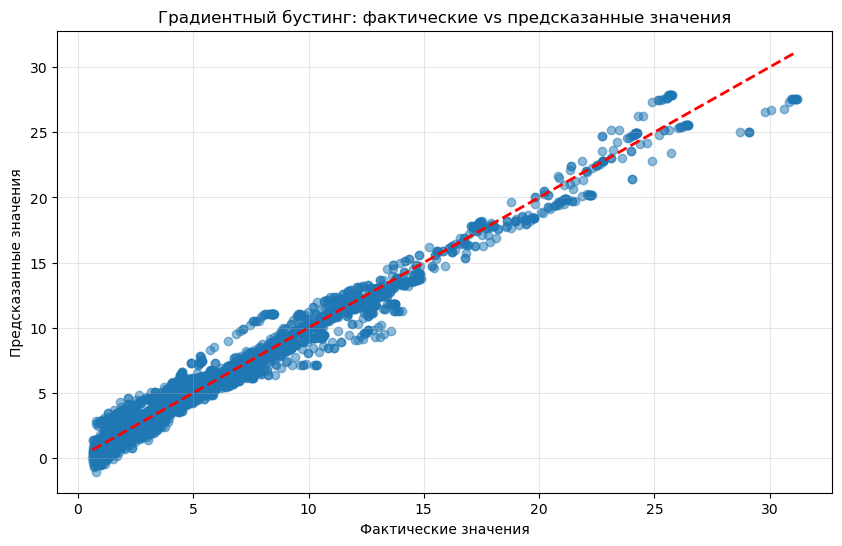

In [34]:
# Модель градиентного бустинга
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Обучение модели
gb_model.fit(X_train_scaled, y_train)

# Предсказание
gb_pred = gb_model.predict(X_test_scaled)

# Оценка модели
gb_mse = mean_squared_error(y_test, gb_pred)
gb_r2 = r2_score(y_test, gb_pred)
gb_max_err = max_error(y_test, gb_pred)

print("Градиентный бустинг:")
print(f"MSE: {gb_mse:.6f}")
print(f"R²: {gb_r2:.6f}")
print(f"Max Error: {gb_max_err:.6f}")

# Визуализация результатов
plt.figure(figsize=(10, 6))
plt.scatter(y_test, gb_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title('Градиентный бустинг: фактические vs предсказанные значения')
plt.grid(True, alpha=0.3)
plt.show()

Градиентный бустинг:
MSE: 0.071948
R²: 0.997186
Max Error: 4.134855


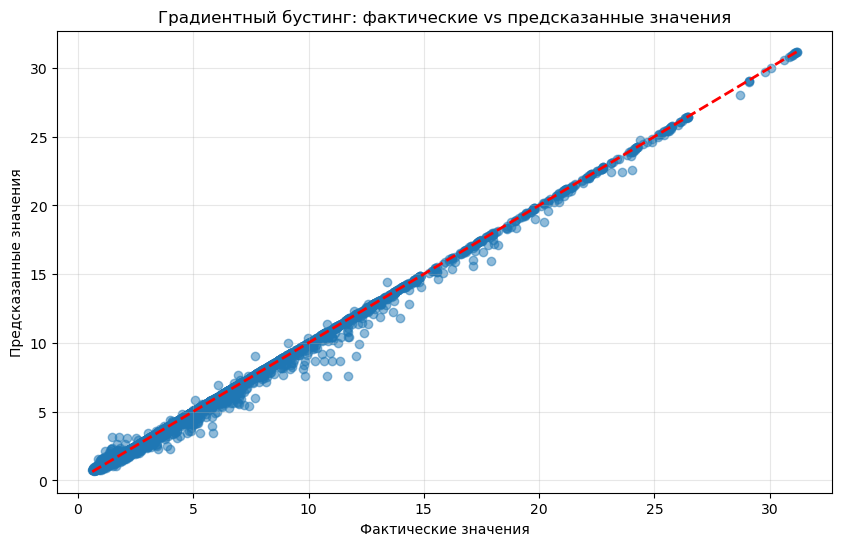

In [35]:
from sklearn.neighbors import KNeighborsRegressor
knn_model = KNeighborsRegressor(n_neighbors=2, weights='distance')

# Обучение модели
knn_model.fit(X_train, y_train)

# Предсказание
knn_pred = knn_model.predict(X_test)

# Оценка модели
knn_mse = mean_squared_error(y_test, knn_pred)
knn_r2 = r2_score(y_test, knn_pred)
knn_max_err = max_error(y_test, knn_pred)

print("Градиентный бустинг:")
print(f"MSE: {knn_mse:.6f}")
print(f"R²: {knn_r2:.6f}")
print(f"Max Error: {knn_max_err:.6f}")

# Визуализация результатов
plt.figure(figsize=(10, 6))
plt.scatter(y_test, knn_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title('Градиентный бустинг: фактические vs предсказанные значения')
plt.grid(True, alpha=0.3)
plt.show()

### Модель из другого пакета (XGBoost)

In [36]:
# Модель XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Обучение модели
xgb_model.fit(X_train_scaled, y_train)

# Предсказание
xgb_pred = xgb_model.predict(X_test_scaled)

# Оценка модели
xgb_mse = mean_squared_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)
xgb_max_err = max_error(y_test, xgb_pred)

print("\nXGBoost:")
print(f"MSE: {xgb_mse:.6f}")
print(f"R²: {xgb_r2:.6f}")
print(f"Max Error: {xgb_max_err:.6f}")


XGBoost:
MSE: 0.102753
R²: 0.995982
Max Error: 1.591830


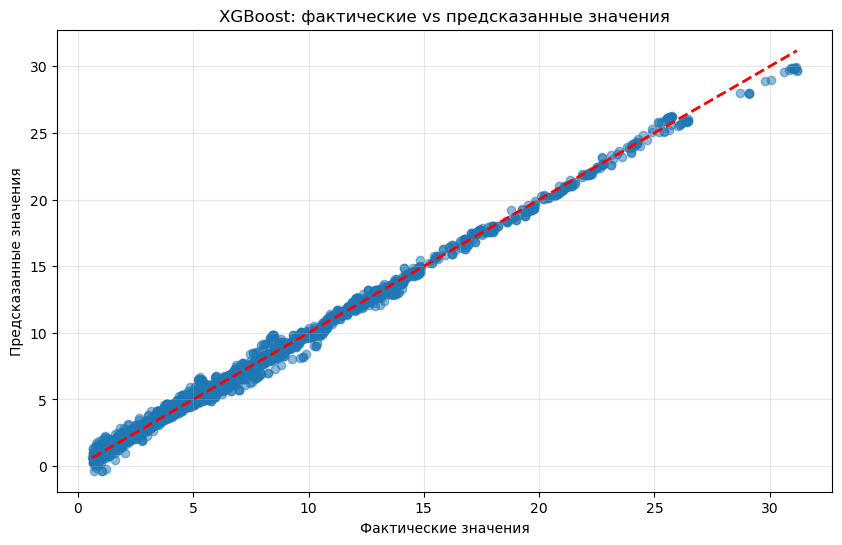

In [37]:
# Визуализация результатов
plt.figure(figsize=(10, 6))
plt.scatter(y_test, xgb_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title('XGBoost: фактические vs предсказанные значения')
plt.grid(True, alpha=0.3)
plt.show()

### Сравнение всех моделей


Сравнение всех моделей:
               Model        MSE        R²  Max Error
0  Linear Regression  17.477756  0.316488  20.551515
1                SVR   6.704084  0.737820  14.314422
2  Gradient Boosting   0.692229  0.972929   4.071449
3            XGBoost   0.102753  0.995982   1.591830


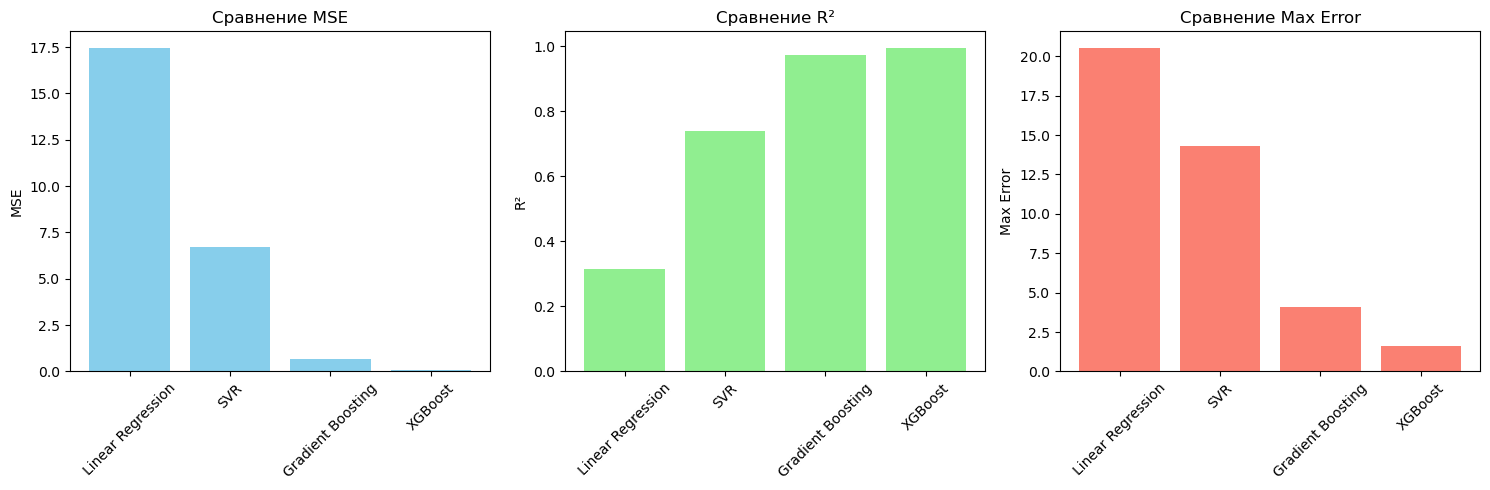

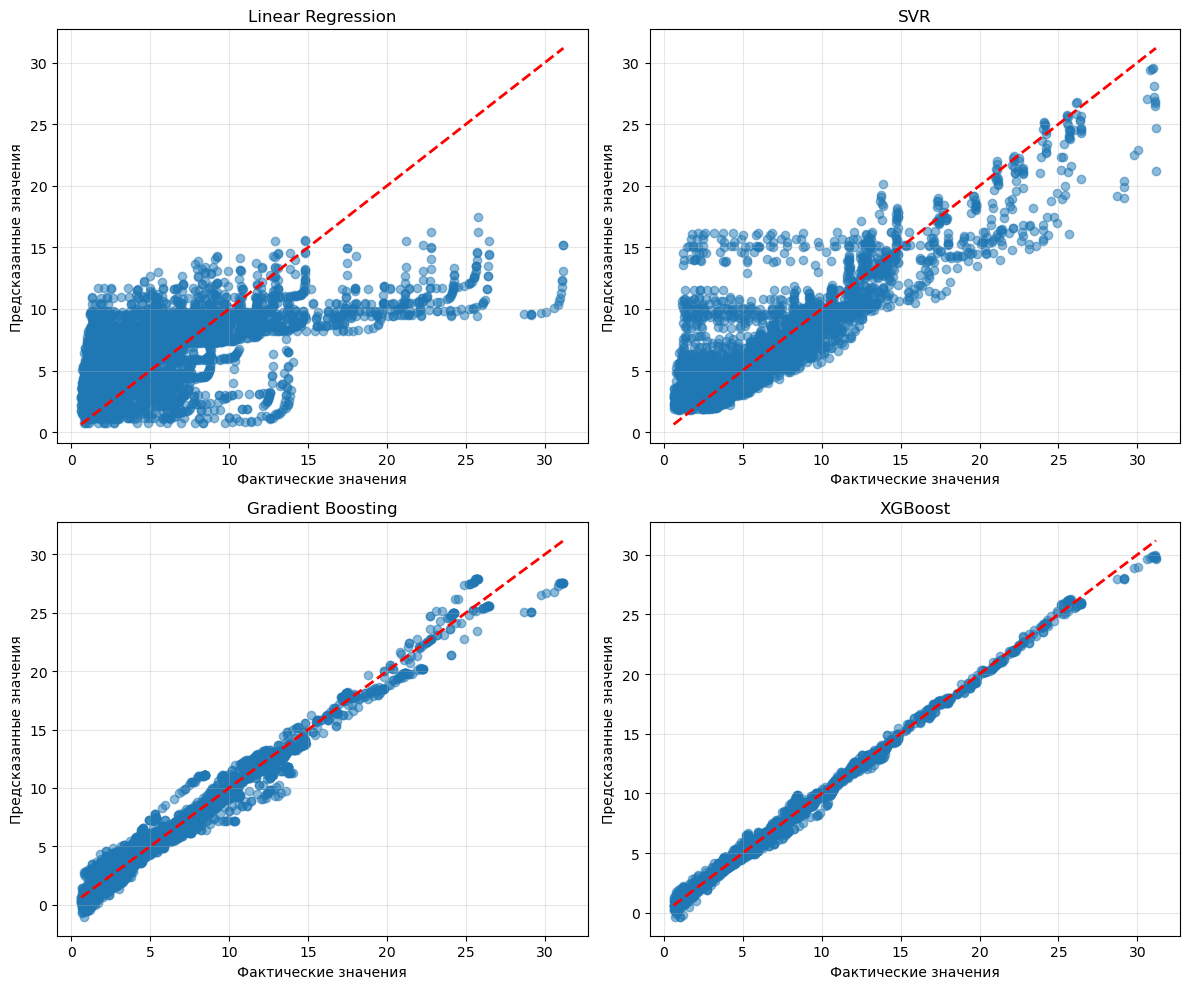

In [ ]:
# Собираем результаты всех моделей
results = {
    'Model': ['Linear Regression',  'SVR', 'Gradient Boosting','XGBoost'],
    'MSE': [lr_mse, svr_mse, gb_mse, xgb_mse],
    'R²': [lr_r2, svr_r2, gb_r2, xgb_r2],
    'Max Error': [lr_max_err, svr_max_err, gb_max_err, xgb_max_err]
}

results_df = pd.DataFrame(results)
print("\nСравнение всех моделей:")
print(results_df)

# Визуализация сравнения
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Сравнение MSE
axes[0].bar(results_df['Model'], results_df['MSE'], color='skyblue')
axes[0].set_title('Сравнение MSE')
axes[0].set_ylabel('MSE')
axes[0].tick_params(axis='x', rotation=45)

# Сравнение R²
axes[1].bar(results_df['Model'], results_df['R²'], color='lightgreen')
axes[1].set_title('Сравнение R²')
axes[1].set_ylabel('R²')
axes[1].tick_params(axis='x', rotation=45)

# Сравнение Max Error
axes[2].bar(results_df['Model'], results_df['Max Error'], color='salmon')
axes[2].set_title('Сравнение Max Error')
axes[2].set_ylabel('Max Error')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Визуализация предсказаний всех моделей
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
predictions = [lr_pred, svr_pred, gb_pred, xgb_pred]
model_names = ['Linear Regression',  'SVR', 'Gradient Boosting','XGBoost']

for idx, (ax, pred, name) in enumerate(zip(axes.flat, predictions, model_names)):
    ax.scatter(y_test, pred, alpha=0.5)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set_xlabel('Фактические значения')
    ax.set_ylabel('Предсказанные значения')
    ax.set_title(f'{name}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Влияние размера обучающей выборки на качество

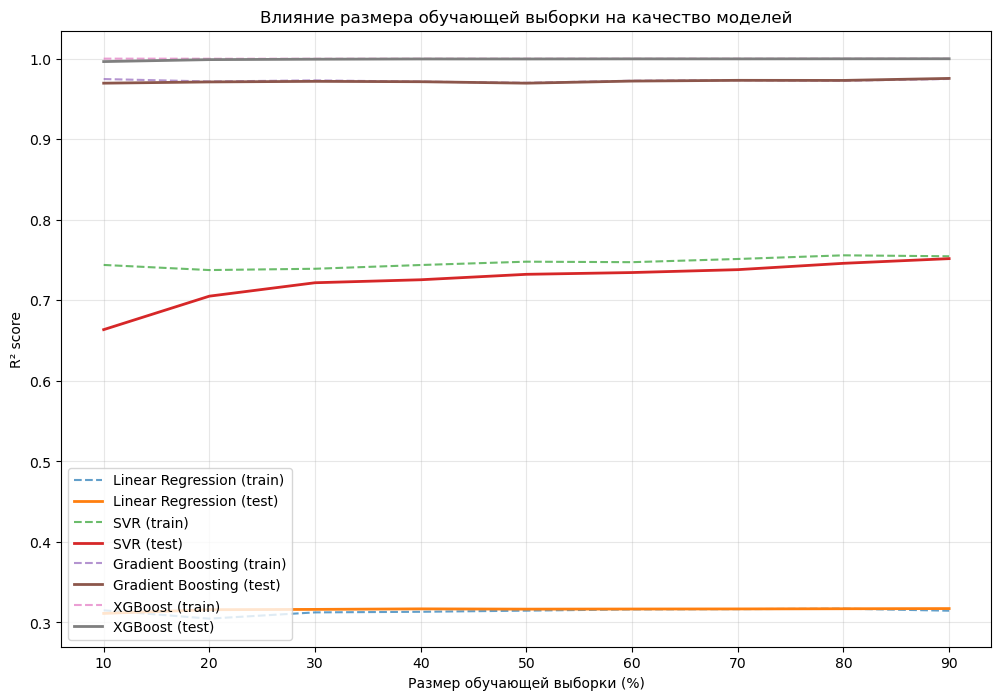

In [45]:
def evaluate_learning_curve(model):
    """Оценка влияния размера выборки на качество модели"""
    train_sizes = np.linspace(0.1, 0.9, 9)
    train_scores = []
    test_scores = []
    
    for train_size in train_sizes:
        # Разделение данных
        X_train_sub, _, y_train_sub, _ = train_test_split(
            X, y, train_size=train_size, random_state=42
        )
        
        # Масштабирование
        scaler_sub = StandardScaler()
        X_train_sub_scaled = scaler_sub.fit_transform(X_train_sub)
        X_test_scaled_sub = scaler_sub.transform(X_test)
        
        # Обучение модели
        model_clone = clone(model)
        model_clone.fit(X_train_sub_scaled, y_train_sub)
        
        # Предсказание
        y_pred = model_clone.predict(X_test_scaled_sub)
        
        # Оценка
        train_score = r2_score(y_train_sub, model_clone.predict(X_train_sub_scaled))
        test_score = r2_score(y_test, y_pred)
        
        train_scores.append(train_score)
        test_scores.append(test_score)
    
    return train_sizes, train_scores, test_scores

# Создаем список моделей для анализа
models = [
    (LinearRegression(), "Linear Regression"),
    (SVR(C=100, epsilon=1, kernel='rbf'), "SVR"),
    (GradientBoostingRegressor(n_estimators=100, random_state=42), "Gradient Boosting"),
    (xgb.XGBRegressor(n_estimators=100, random_state=42), "XGBoost")
]

# Анализ кривых обучения
plt.figure(figsize=(12, 8))

for model, name in models:
    train_sizes, train_scores, test_scores = evaluate_learning_curve(model)
    
    plt.plot(train_sizes * 100, train_scores, '--', label=f'{name} (train)', alpha=0.7)
    plt.plot(train_sizes * 100, test_scores, '-', label=f'{name} (test)', linewidth=2)

plt.xlabel('Размер обучающей выборки (%)')
plt.ylabel('R² score')
plt.title('Влияние размера обучающей выборки на качество моделей')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Нейросетевые модели

In [16]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import KFold
import tensorflow.keras.backend as K
import warnings
warnings.filterwarnings('ignore')

In [17]:
def max_error_metric(y_true, y_pred):
    """
    Кастомная метрика для расчета максимальной абсолютной ошибки
    """
    return K.max(K.abs(y_true - y_pred))

# 1. Создание нейросетевой модели
def create_nn_model(input_dim, 
                    hidden_layers=[64, 32, 16], 
                    dropout_rate=0.2,
                    learning_rate=0.001):
    """
    Создает нейросетевую модель для регрессии
    
    Parameters:
    -----------
    input_dim : int
        Размерность входных данных
    hidden_layers : list
        Количество нейронов в каждом скрытом слое
    dropout_rate : float
        Rate для Dropout слоев
    learning_rate : float
        Learning rate для оптимизатора
    """
    model = keras.Sequential()
    
    # Входной слой
    model.add(layers.Input(shape=(input_dim,)))
    
    # Добавляем скрытые слои
    for i, neurons in enumerate(hidden_layers):
        model.add(layers.Dense(neurons, activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(dropout_rate))
    
    # Выходной слой (линейная активация для регрессии)
    model.add(layers.Dense(1, activation='linear'))
    
    # Компиляция модели
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='mse',  # Mean Squared Error для регрессии
        metrics=[max_error_metric, 'mse']  # Максимальная ошибка и MSE
    )
    
    return model

# 2. Обучение нейросетевой модели
def train_nn_model(X_train_scaled, y_train, X_test_scaled, y_test, 
                   epochs=200, batch_size=32, patience=20):
    """
    Обучает нейросетевую модель с использованием ранней остановки
    """
    # Создаем модель
    model = create_nn_model(
        input_dim=X_train_scaled.shape[1],
        hidden_layers=[512, 256, 64, 16],
        dropout_rate=0.3,
        learning_rate=0.001
    )
    
    # Callbacks для улучшения обучения
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=10,
            min_lr=1e-6,
            verbose=1
        )
    ]
    
    # Обучение модели
    print("Обучение нейросетевой модели...")
    history = model.fit(
        X_train_scaled, y_train,
        validation_split=0.1,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=0
    )
    
    # Предсказание на тестовых данных
    y_pred = model.predict(X_test_scaled, verbose=0).flatten()
    
    # Оценка модели
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    me = np.max(np.abs(y_test - y_pred))
    
    return model, history, y_pred, {'mse': mse, 'r2': r2, 'me': me}


In [18]:
# Обучение модели
nn_model, nn_history, nn_pred, nn_metrics = train_nn_model(
    X_train_scaled, y_train, X_test_scaled, y_test,
    epochs=300,
    batch_size=16,
    patience=25
)

print(f"\nМетрики нейросетевой модели:")
print(f"MSE: {nn_metrics['mse']:.6f}")
print(f"R²: {nn_metrics['r2']:.6f}")
print(f"Max Error: {nn_metrics['me']:.6f}")

Обучение нейросетевой модели...

Epoch 53: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 76: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 98: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 133: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 154: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 181: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.

Epoch 198: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.

Epoch 209: ReduceLROnPlateau reducing learning rate to 3.906250185536919e-06.

Epoch 224: ReduceLROnPlateau reducing learning rate to 1.9531250927684596e-06.

Epoch 241: ReduceLROnPlateau reducing learning rate to 1e-06.
Epoch 277: early stopping
Restoring model weights from the end of the best epoch: 252.

Метрики нейросетевой модели:
MSE: 0.576366
R²: 0.977460
Max Error: 4.274378


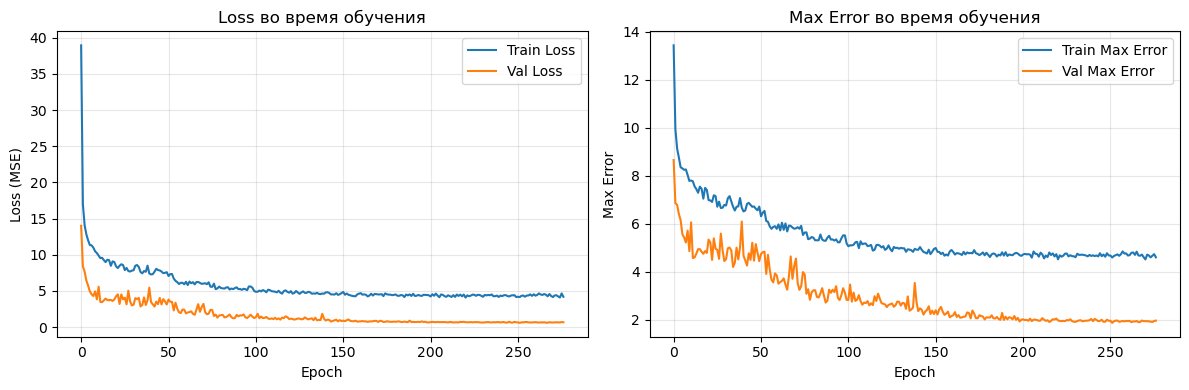

In [25]:
# Визуализация обучения
def plot_training_history(history):
    """Визуализация истории обучения"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Loss
    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title('Loss во время обучения')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss (MSE)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Max Error
    axes[1].plot(history.history['max_error_metric'], label='Train Max Error')
    axes[1].plot(history.history['val_max_error_metric'], label='Val Max Error')
    axes[1].set_title('Max Error во время обучения')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Max Error')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_training_history(nn_history)

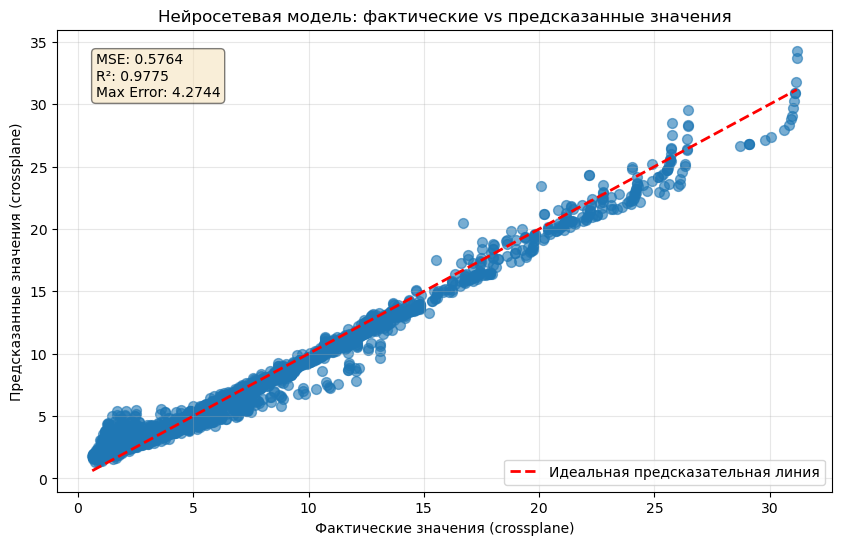

In [27]:
# Визуализация предсказаний
plt.figure(figsize=(10, 6))
plt.scatter(y_test, nn_pred, alpha=0.6, s=50)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Идеальная предсказательная линия')
plt.xlabel('Фактические значения (crossplane)')
plt.ylabel('Предсказанные значения (crossplane)')
plt.title('Нейросетевая модель: фактические vs предсказанные значения')
plt.legend()
plt.grid(True, alpha=0.3)

# Добавляем текст с метриками
metrics_text = f"MSE: {nn_metrics['mse']:.4f}\nR²: {nn_metrics['r2']:.4f}\nMax Error: {nn_metrics['me']:.4f}"
plt.text(0.05, 0.95, metrics_text, transform=plt.gca().transAxes,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.show()


Сравнение всех моделей:
               Model        MSE        R²  Max Error
0  Linear Regression  17.477756  0.316488  20.551515
1                SVR   6.704084  0.737820  14.314422
2  Gradient Boosting   0.692229  0.972929   4.071449
3            XGBoost   0.102753  0.995982   1.591830
4     Neural Network   0.576366  0.977460   4.274378


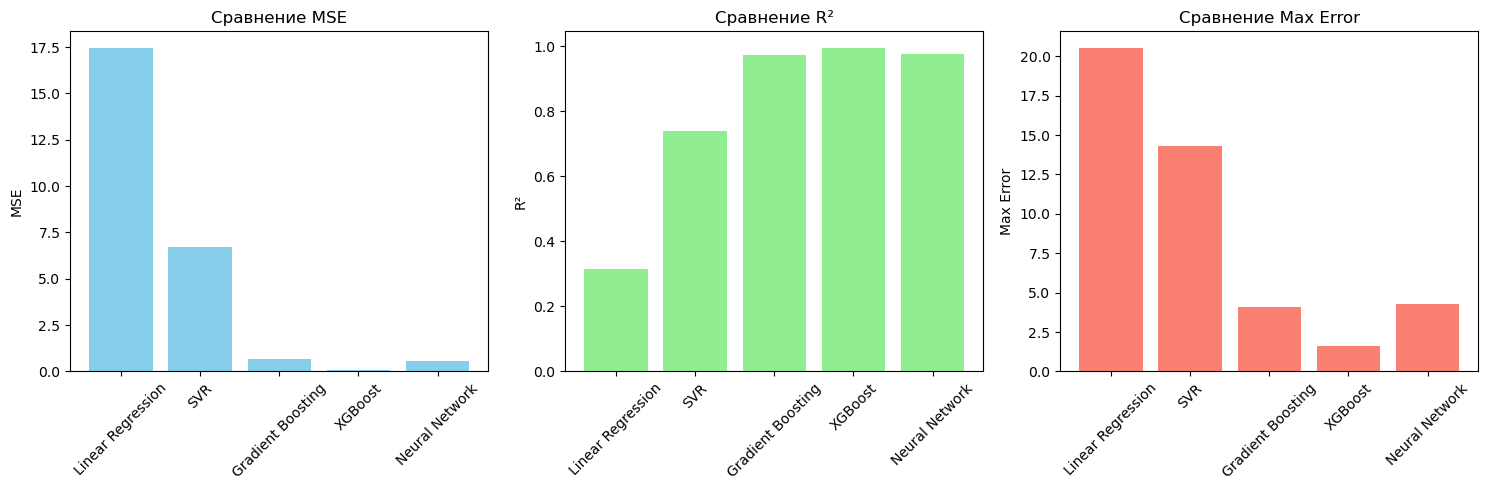

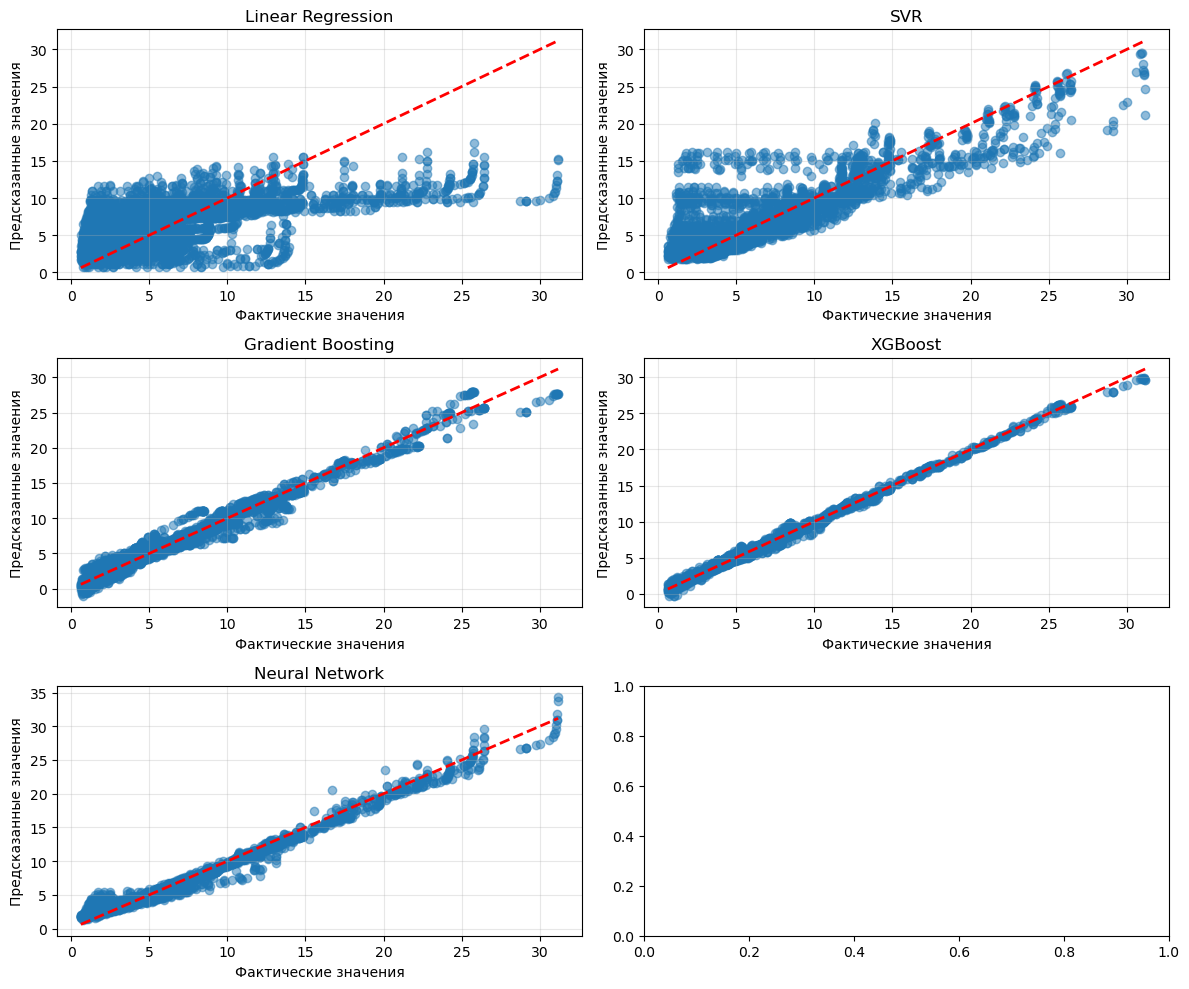

In [38]:
# Собираем результаты всех моделей
results = {
    'Model': ['Linear Regression',  'SVR', 'Gradient Boosting','XGBoost', 'Neural Network'],
    'MSE': [lr_mse, svr_mse, gb_mse, xgb_mse, nn_metrics['mse']],
    'R²': [lr_r2, svr_r2, gb_r2, xgb_r2, nn_metrics['r2']],
    'Max Error': [lr_max_err, svr_max_err, gb_max_err, xgb_max_err, nn_metrics['me']]
}

results_df = pd.DataFrame(results)
print("\nСравнение всех моделей:")
print(results_df)

# Визуализация сравнения
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Сравнение MSE
axes[0].bar(results_df['Model'], results_df['MSE'], color='skyblue')
axes[0].set_title('Сравнение MSE')
axes[0].set_ylabel('MSE')
axes[0].tick_params(axis='x', rotation=45)

# Сравнение R²
axes[1].bar(results_df['Model'], results_df['R²'], color='lightgreen')
axes[1].set_title('Сравнение R²')
axes[1].set_ylabel('R²')
axes[1].tick_params(axis='x', rotation=45)

# Сравнение Max Error
axes[2].bar(results_df['Model'], results_df['Max Error'], color='salmon')
axes[2].set_title('Сравнение Max Error')
axes[2].set_ylabel('Max Error')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Визуализация предсказаний всех моделей
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
predictions = [lr_pred, svr_pred, gb_pred, xgb_pred, nn_pred]
model_names = ['Linear Regression',  'SVR', 'Gradient Boosting','XGBoost', 'Neural Network']

for idx, (ax, pred, name) in enumerate(zip(axes.flat, predictions, model_names)):
    ax.scatter(y_test, pred, alpha=0.5)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set_xlabel('Фактические значения')
    ax.set_ylabel('Предсказанные значения')
    ax.set_title(f'{name}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()